In [1]:
pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from keras_tuner import RandomSearch

In [3]:
# Step 1: Load the dataset - Make sure the file is in the same folder
print("Dataset Loaded ")
data = pd.read_csv("/content/Crop_recommendation.csv")
print(data.head())

Dataset Loaded 
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [4]:
# Step 2: Prepare Features (X) and Target (y)
X = data[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = data['label']

In [5]:
# Step 3: Encode the crop names into numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [6]:
# Step 4: Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(
X, y_encoded, test_size=0.2, random_state=42)

In [7]:
# Step 5: Scale the features (standardize values)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Step 6: Define a function to build the model with tunable parameters
def build_model(hp):
    model = Sequential()

    # First hidden layer with variable units
    model.add(
        Dense(
            units=hp.Int('units_1', 32, 256, step=32),
            activation='relu',
            input_shape=(X_train.shape[1],)
        )
    )

    # Second hidden layer with variable units
    model.add(
        Dense(
            units=hp.Int('units_2', 32, 256, step=32),
            activation='relu'
        )
    )

    # Output layer (22 crop classes)
    model.add(
        Dense(
            len(np.unique(y_encoded)),
            activation='softmax'
        )
    )

    # Compile the model
    model.compile(
        optimizer=Adam(
            learning_rate=hp.Float('lr', 1e-4, 1e-2, sampling='LOG')
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [9]:
# Step 7: Setup Keras Tuner for Hyperparameter Tuning
tuner = RandomSearch(
  build_model,
  objective='val_accuracy',
  max_trials=5, # Number of combinations to try
  executions_per_trial=1, # Run each trial once
  directory='tuner_results',
  project_name='crop_recommendation',
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Step 8: Add EarlyStopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3)


In [11]:
# Step 9: Start the tuning process
print("Starting Hyperparameter Tuning...")

tuner.search(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Trial 5 Complete [00h 00m 15s]
val_accuracy: 0.9659090638160706

Best val_accuracy So Far: 0.9857954382896423
Total elapsed time: 00h 01m 11s


In [12]:
# Step 10: Get the best model
best_model = tuner.get_best_models(1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [13]:
# Step 11: Train the best model again and store training history
history = best_model.fit(X_train, y_train,
validation_split=0.2,
epochs=50,
batch_size=32,
callbacks=[early_stop],
verbose=1)


Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9851 - loss: 0.0401 - val_accuracy: 0.9858 - val_loss: 0.0589
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9872 - loss: 0.0346 - val_accuracy: 0.9688 - val_loss: 0.0720
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9893 - loss: 0.0289 - val_accuracy: 0.9801 - val_loss: 0.0526
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9865 - loss: 0.0347 - val_accuracy: 0.9688 - val_loss: 0.0767
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9886 - loss: 0.0303 - val_accuracy: 0.9773 - val_loss: 0.0530
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9922 - loss: 0.0227 - val_accuracy: 0.9716 - val_loss: 0.0684


In [14]:
# Step 12: Evaluate the model
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9727 - loss: 0.0892  

Test Accuracy: 97.27%


In [15]:
# Step 13: Show best hyperparameters
best_hp = tuner.get_best_hyperparameters(1)[0]
print("\n Best Hyperparameters Found:")
print(" - Units in Layer 1:", best_hp.get('units_1'))
print(" - Units in Layer 2:", best_hp.get('units_2'))
print(" - Learning Rate:", best_hp.get('lr'))


 Best Hyperparameters Found:
 - Units in Layer 1: 128
 - Units in Layer 2: 224
 - Learning Rate: 0.001078858555498738


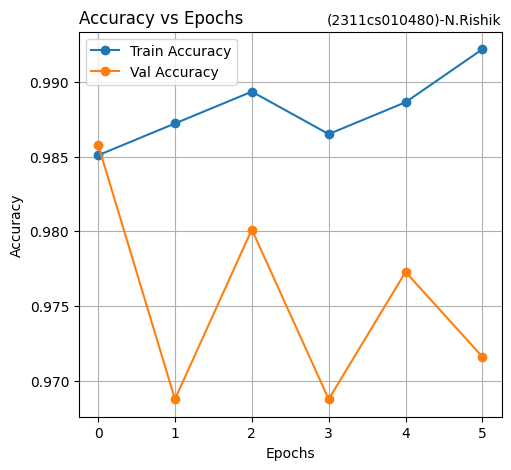

In [16]:
# Step 14: Plot Accuracy and Loss
plt.figure(figsize=(12, 5))
# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title("Accuracy vs Epochs",loc='left')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.text(1.0,1.02,'(2311cs010480)-N.Rishik',transform=plt.gca().transAxes,ha='right')
plt.legend()
plt.grid(True)

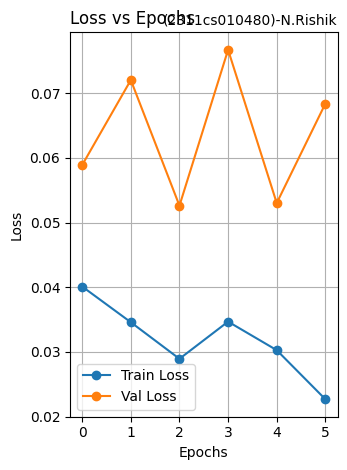

In [17]:
# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title("Loss vs Epochs",loc='left')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.text(1.0,1.02,'(2311cs010480)-N.Rishik',transform=plt.gca().transAxes,ha='right')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
# Step 15: Make a prediction on a sample
sample = X_test[5:6]

predicted_crop = best_model.predict(sample)

predicted_label = label_encoder.inverse_transform(
    [np.argmax(predicted_crop)]
)

print(f"\nPredicted Crop for Sample: {predicted_label[0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

Predicted Crop for Sample: mango
